# DESAFIO 06 - Qualidade do Ar
#
| Campo | Informação |
|---|---|
| **Curso:** | IA |
| **Termo:** | III / 3 | |
| **Disciplina:** | Algoritmos de I ARTIFICIAL (Classificadores) |
| **Nome dos alunos:** | Felipe Augusto Santos Dorta de Oliveira, Bruno Marcelo Rocha da Silva, Lucas de Azevedo Kopeska Paraizo
| **RA dos alunos:** | 2052799, 1988442, 2054984|
---

## Objetivo
Classificar a qualidade do ar como **"boa"** ou **"ruim"** com base em concentrações de poluentes.

> **Dataset:** UCI Air Quality — medições horárias de poluentes e condições meteorológicas em uma cidade italiana (2004–2005).


## Etapa 1 — Importações e Carregamento dos Dados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              ConfusionMatrixDisplay, RocCurveDisplay)

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
np.random.seed(42)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
# Carregar o dataset
# O separador é ponto e vírgula (;) e o decimal é vírgula (,)
df = pd.read_csv('AirQuality.csv', sep=';', decimal=',')

# Remover colunas vazias que o CSV gera no final
df = df.drop(columns=['Unnamed: 15', 'Unnamed: 16'])

print("=== PRIMEIRAS LINHAS ===")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"Colunas: {df.columns.tolist()}")

=== PRIMEIRAS LINHAS ===
         Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
0  10/03/2004  18.00.00     2.6       1360.0     150.0      11.9   
1  10/03/2004  19.00.00     2.0       1292.0     112.0       9.4   
2  10/03/2004  20.00.00     2.2       1402.0      88.0       9.0   
3  10/03/2004  21.00.00     2.2       1376.0      80.0       9.2   
4  10/03/2004  22.00.00     1.6       1272.0      51.0       6.5   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0         1046.0    166.0        1056.0    113.0        1692.0       1268.0   
1          955.0    103.0        1174.0     92.0        1559.0        972.0   
2          939.0    131.0        1140.0    114.0        1555.0       1074.0   
3          948.0    172.0        1092.0    122.0        1584.0       1203.0   
4          836.0    131.0        1205.0    116.0        1490.0       1110.0   

      T    RH      AH  
0  13.6  48.9  0.7578  
1  13.3  47.7  0.7255  
2  11.9  54.0  0.75

## Etapa 2 — Análise Exploratória (EDA)

### 2.1 Informações gerais do dataset

In [3]:
print("=== INFORMAÇÕES DO DATASET ===")
df.info()

print("\n=== ESTATÍSTICAS DESCRITIVAS ===")
print(df.describe().round(2))

=== INFORMAÇÕES DO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.1+ MB

=== ESTATÍSTICAS DESCRITIVAS ===
        CO(GT)  PT08.S1(CO)

### 2.2 Valores -200 (representam dados faltantes)

In [4]:
# O dataset usa -200 para indicar dados ausentes
# Vamos contar quantos existem em cada coluna numérica
print("=== CONTAGEM DE VALORES -200 POR COLUNA ===")

colunas_numericas = df.select_dtypes(include='number').columns
for col in colunas_numericas:
    n = (df[col] == -200).sum()
    pct = n / len(df) * 100
    print(f"  {col:<22}: {n:>5} valores missing ({pct:.1f}%)")

=== CONTAGEM DE VALORES -200 POR COLUNA ===
  CO(GT)                :  1683 valores missing (17.8%)
  PT08.S1(CO)           :   366 valores missing (3.9%)
  NMHC(GT)              :  8443 valores missing (89.1%)
  C6H6(GT)              :   366 valores missing (3.9%)
  PT08.S2(NMHC)         :   366 valores missing (3.9%)
  NOx(GT)               :  1639 valores missing (17.3%)
  PT08.S3(NOx)          :   366 valores missing (3.9%)
  NO2(GT)               :  1642 valores missing (17.3%)
  PT08.S4(NO2)          :   366 valores missing (3.9%)
  PT08.S5(O3)           :   366 valores missing (3.9%)
  T                     :   366 valores missing (3.9%)
  RH                    :   366 valores missing (3.9%)
  AH                    :   366 valores missing (3.9%)


### 2.3 Distribuição dos poluentes principais

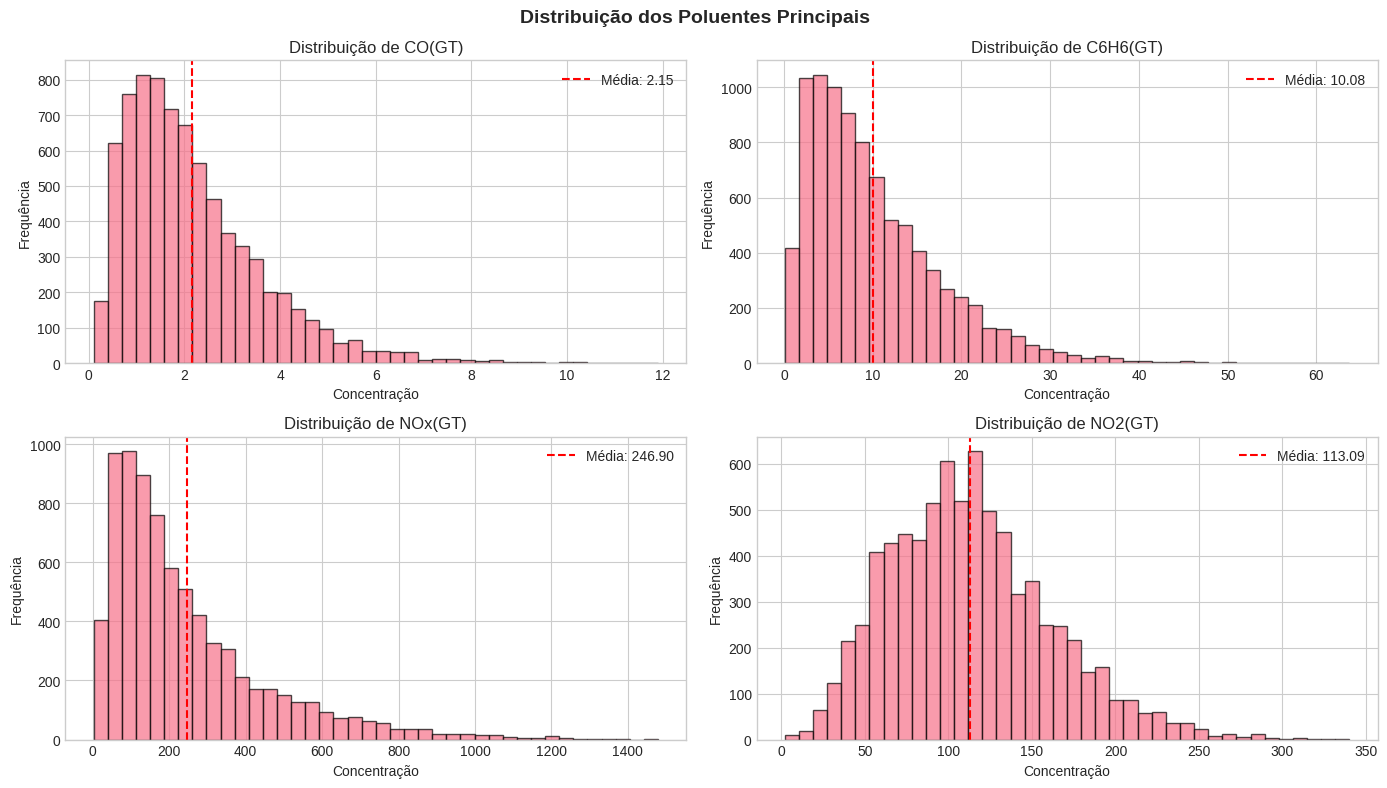

In [5]:
# Substituir -200 por NaN para análises visuais
df_plot = df.replace(-200, np.nan)

poluentes = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for i, col in enumerate(poluentes):
    dados = df_plot[col].dropna()
    axes[i].hist(dados, bins=40, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribuição de {col}')
    axes[i].set_xlabel('Concentração')
    axes[i].set_ylabel('Frequência')
    media = dados.mean()
    axes[i].axvline(media, color='red', linestyle='--', label=f'Média: {media:.2f}')
    axes[i].legend()

plt.suptitle('Distribuição dos Poluentes Principais', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4 Criando a variável alvo (target)

Como o dataset não tem PM2.5, usamos o **CO(GT)** como poluente principal.  
Critério adaptado do padrão OMS:
- **CO ≥ 2 µg/m³** → qualidade **"ruim"** (1)  
- **CO < 2 µg/m³** → qualidade **"boa"** (0)

> Os valores -200 são substituídos por NaN e as linhas com missing no CO são removidas.


=== DISTRIBUIÇÃO DA VARIÁVEL ALVO ===
Boa  (0): 4125 amostras (53.8%)
Ruim (1): 3549 amostras (46.2%)


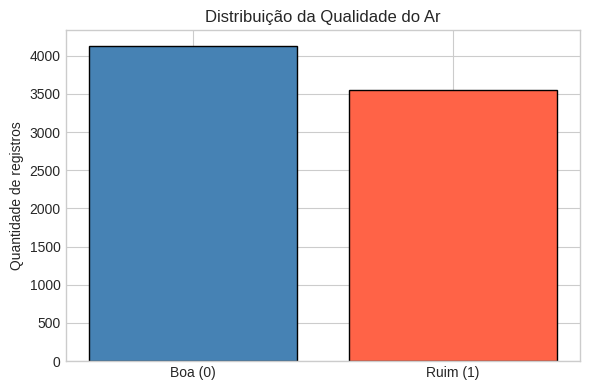

In [6]:
# Substituir -200 por NaN em todo o dataframe
df = df.replace(-200, np.nan)

LIMIAR_CO = 2.0

# Criar features temporais (precisamos disso antes do dropna)
df['Date']       = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['mes']        = df['Date'].dt.month
df['dia_semana'] = df['Date'].dt.dayofweek   # 0 = Segunda, 6 = Domingo
df['hora']       = df['Time'].fillna('00.00.00').str[:2].astype(int)

# Criar a estação do ano
def get_estacao(mes):
    if mes in [12, 1, 2]:   return 'Inverno'
    elif mes in [3, 4, 5]:  return 'Primavera'
    elif mes in [6, 7, 8]:  return 'Verão'
    else:                    return 'Outono'

df['estacao'] = df['mes'].apply(get_estacao)

# Mostrar distribuição do target
co_valido = df['CO(GT)'].dropna()
target_temp = (co_valido >= LIMIAR_CO).astype(int)

print("=== DISTRIBUIÇÃO DA VARIÁVEL ALVO ===")
print(f"Boa  (0): {(target_temp==0).sum()} amostras ({(target_temp==0).mean()*100:.1f}%)")
print(f"Ruim (1): {(target_temp==1).sum()} amostras ({(target_temp==1).mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Boa (0)', 'Ruim (1)'],
       [(target_temp==0).sum(), (target_temp==1).sum()],
       color=['steelblue', 'tomato'], edgecolor='black')
ax.set_title('Distribuição da Qualidade do Ar')
ax.set_ylabel('Quantidade de registros')
plt.tight_layout()
plt.show()

### 2.5 Correlação entre variáveis

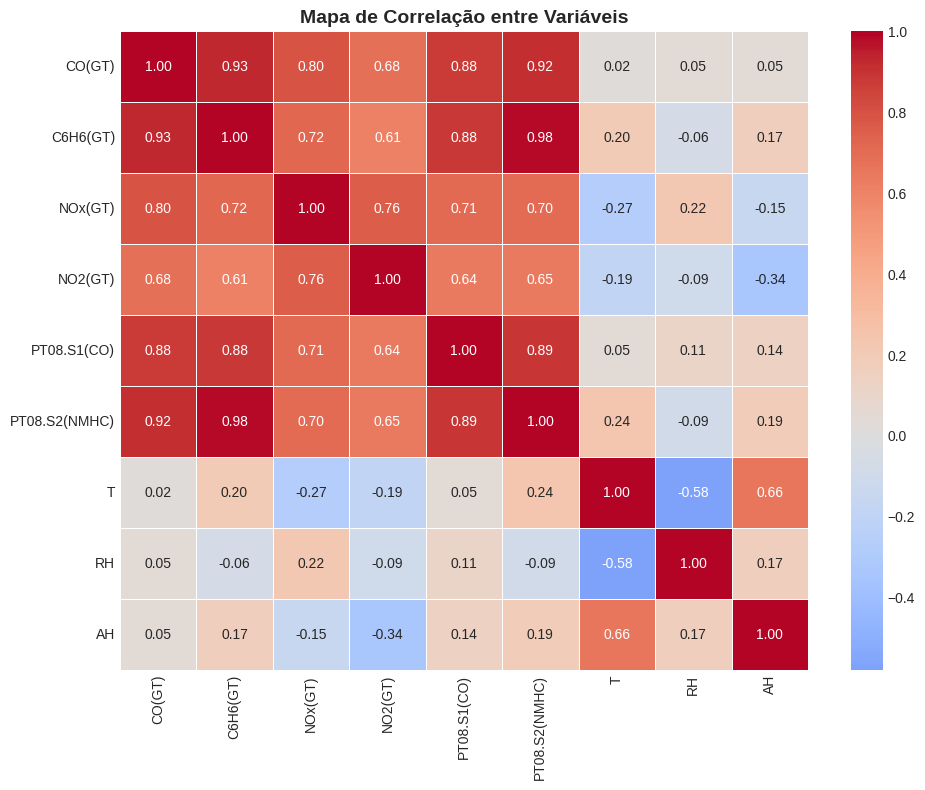

=== CORRELAÇÃO COM CO(GT) — nosso poluente-alvo ===
C6H6(GT)         0.931
PT08.S2(NMHC)    0.916
PT08.S1(CO)      0.879
NOx(GT)          0.795
NO2(GT)          0.683
RH               0.049
AH               0.049
T                0.022
Name: CO(GT), dtype: float64


In [7]:
colunas_corr = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)',
                'PT08.S1(CO)', 'PT08.S2(NMHC)', 'T', 'RH', 'AH']

corr = df[colunas_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Mapa de Correlação entre Variáveis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlação com o CO (nosso target)
print("=== CORRELAÇÃO COM CO(GT) — nosso poluente-alvo ===")
print(corr['CO(GT)'].drop('CO(GT)').sort_values(ascending=False).round(3))

### 2.6 Sazonalidade — Qual estação tem pior qualidade?

=== % DE REGISTROS COM QUALIDADE RUIM POR ESTAÇÃO ===
  Outono      : 55.0%
  Inverno     : 50.6%
  Primavera   : 46.2%
  Verão       : 32.6%


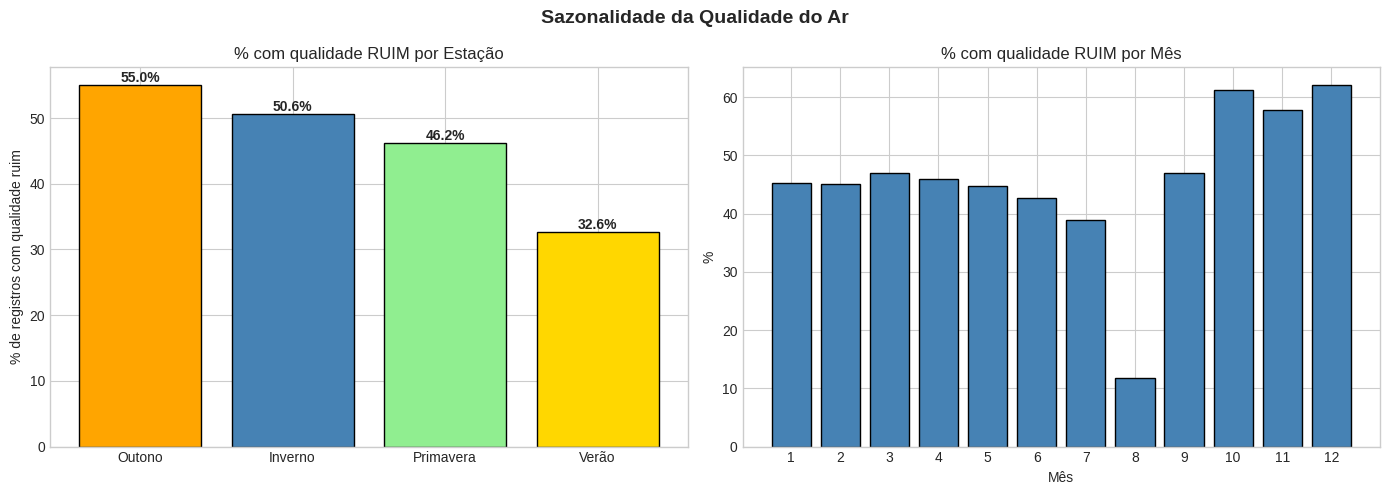


=> A estação com PIOR qualidade do ar é: Outono (55.0% ruim)


In [8]:
# Calcular proporção de dias 'ruins' por estação e por mês
# (usando o dataframe antes do dropna final)
df_saz = df[['estacao', 'mes', 'CO(GT)']].dropna()
df_saz['ruim'] = (df_saz['CO(GT)'] >= LIMIAR_CO).astype(int)

sazonal = df_saz.groupby('estacao')['ruim'].mean().sort_values(ascending=False)
mensal  = df_saz.groupby('mes')['ruim'].mean() * 100

print("=== % DE REGISTROS COM QUALIDADE RUIM POR ESTAÇÃO ===")
for est, val in sazonal.items():
    print(f"  {est:<12}: {val*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cores = {'Inverno': 'steelblue', 'Outono': 'orange',
         'Verão': 'gold', 'Primavera': 'lightgreen'}
estacoes_ord = sazonal.index
vals = sazonal.values * 100
cores_list = [cores[e] for e in estacoes_ord]

axes[0].bar(estacoes_ord, vals, color=cores_list, edgecolor='black')
axes[0].set_title('% com qualidade RUIM por Estação')
axes[0].set_ylabel('% de registros com qualidade ruim')
for i, v in enumerate(vals):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

axes[1].bar(mensal.index, mensal.values, color='steelblue', edgecolor='black')
axes[1].set_title('% com qualidade RUIM por Mês')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('%')
axes[1].set_xticks(range(1, 13))

plt.suptitle('Sazonalidade da Qualidade do Ar', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

pior = sazonal.idxmax()
print(f"\n=> A estação com PIOR qualidade do ar é: {pior} ({sazonal[pior]*100:.1f}% ruim)")

## Etapa 3 — Pré-processamento

### 3.1 Seleção de features e limpeza dos dados

In [9]:
# Features selecionadas (preditores)
# NMHC(GT) foi excluído pois tem ~89% de missing
features = ['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)',
            'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
            'PT08.S5(O3)', 'T', 'RH', 'AH',
            'mes', 'dia_semana', 'hora']

# Criar dataset de modelagem: remover linhas com missing no CO ou nas features
df_modelo = df[features + ['CO(GT)']].dropna(subset=['CO(GT)'] + features).copy()
df_modelo['qualidade_ruim'] = (df_modelo['CO(GT)'] >= LIMIAR_CO).astype(int)

X = df_modelo[features]
y = df_modelo['qualidade_ruim']

print("=== DADOS APÓS LIMPEZA ===")
print(f"Linhas originais:    {len(df)}")
print(f"Linhas após limpeza: {len(df_modelo)}")
print(f"Linhas removidas:    {len(df) - len(df_modelo)}")
print(f"\nShape de X: {X.shape}")
print(f"\nDistribuição do target:")
print(y.value_counts())

=== DADOS APÓS LIMPEZA ===
Linhas originais:    9471
Linhas após limpeza: 6941
Linhas removidas:    2530

Shape de X: (6941, 14)

Distribuição do target:
qualidade_ruim
0    3647
1    3294
Name: count, dtype: int64


### 3.2 Divisão treino / validação / teste (60% / 20% / 20%)

In [10]:
# Passo 1: separar 20% para teste (com estratificação)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Passo 2: do restante, separar 25% para validação (= 20% do total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=42
)

print("=== DIVISÃO DOS DADOS ===")
print(f"Treino:     {len(X_train)} amostras ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validação:  {len(X_val)} amostras ({len(X_val)/len(X)*100:.1f}%)")
print(f"Teste:      {len(X_test)} amostras ({len(X_test)/len(X)*100:.1f}%)")

print("\n=== DISTRIBUIÇÃO DE CLASSES (ESTRATIFICADA) ===")
for nome_split, conj_y in [('Treino', y_train), ('Validação', y_val), ('Teste', y_test)]:
    prop = conj_y.mean() * 100
    print(f"  {nome_split}: {prop:.1f}% ruim")

=== DIVISÃO DOS DADOS ===
Treino:     4164 amostras (60.0%)
Validação:  1388 amostras (20.0%)
Teste:      1389 amostras (20.0%)

=== DISTRIBUIÇÃO DE CLASSES (ESTRATIFICADA) ===
  Treino: 47.5% ruim
  Validação: 47.5% ruim
  Teste: 47.4% ruim


### 3.3 Normalização com StandardScaler

In [11]:
# Fit APENAS no treino para evitar data leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print("Normalização aplicada com StandardScaler.")
print("Média das features no treino após normalização (deve ser ~0):")
print(X_train_sc.mean(axis=0).round(2))

Normalização aplicada com StandardScaler.
Média das features no treino após normalização (deve ser ~0):
[-0.  0. -0.  0.  0.  0. -0.  0.  0.  0.  0.  0.  0. -0.]


## Etapa 4 — Comparação de Classificadores

Vamos treinar e comparar **3 classificadores**:
1. **KNN** (K-Nearest Neighbors) — classificador por distância
2. **Random Forest** — ensemble de árvores (Bagging)
3. **Gradient Boosting** — ensemble por Boosting


### 4.1 Treinando os modelos

In [12]:
modelos = {
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

print(f"{'Modelo':<20} {'Treino':>8} {'Val':>8}")
print("-" * 40)

resultados = {}
for nome, modelo in modelos.items():
    modelo.fit(X_train_sc, y_train)
    acc_tr = modelo.score(X_train_sc, y_train)
    acc_va = modelo.score(X_val_sc, y_val)
    resultados[nome] = {'modelo': modelo, 'acc_treino': acc_tr, 'acc_val': acc_va}
    print(f"{nome:<20} {acc_tr:>8.4f} {acc_va:>8.4f}")

print("\nModelos treinados com sucesso!")

Modelo                 Treino      Val
----------------------------------------
KNN                    0.9464   0.9258
Random Forest          1.0000   0.9467
Gradient Boosting      0.9609   0.9359

Modelos treinados com sucesso!


### 4.2 K-Fold Cross-Validation (k=5)

In [13]:
import numpy as np

# Combinar treino + validação para o cross-validation
X_tv = np.vstack([X_train_sc, X_val_sc])
y_tv = np.hstack([y_train, y_val])

skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== CROSS-VALIDATION ESTRATIFICADO (K=5) ===")
print()

for nome, info in resultados.items():
    scores = cross_val_score(info['modelo'], X_tv, y_tv,
                             cv=skfold, scoring='accuracy')
    print(f"{nome}:")
    print(f"  Scores por fold: {scores.round(4)}")
    print(f"  Média: {scores.mean():.4f}  (+/- {scores.std()*2:.4f})")
    print()

=== CROSS-VALIDATION ESTRATIFICADO (K=5) ===

KNN:
  Scores por fold: [0.9208 0.9199 0.9243 0.909  0.9333]
  Média: 0.9215  (+/- 0.0157)

Random Forest:
  Scores por fold: [0.9415 0.9379 0.9324 0.9351 0.9477]
  Média: 0.9389  (+/- 0.0107)

Gradient Boosting:
  Scores por fold: [0.9334 0.9343 0.9333 0.9288 0.9477]
  Média: 0.9355  (+/- 0.0128)



###4.2.2 Otimização de Hiperparâmetros

In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_base = RandomForestClassifier(random_state=42)

parametros_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [15, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

print("buscando pelos melhores hiperparâmetros")


grid_search = GridSearchCV(estimator=rf_base,
                           param_grid=parametros_grid,
                           cv=5,
                           n_jobs=-1,
                           scoring='f1')

grid_search.fit(X_train_sc, y_train)

print("Otimização concluída com sucesso!")
print("Melhores parâmetros:", grid_search.best_params_)

melhor_modelo_final = grid_search.best_estimator_

buscando pelos melhores hiperparâmetros
Otimização concluída com sucesso!
Melhores parâmetros: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


### 4.3 Avaliação completa no conjunto de teste

In [22]:
print("=== AVALIAÇÃO FINAL NO TESTE ===")
print()

#Atualiza o dicionário
if 'Random Forest' in resultados:
    resultados['Random Forest']['modelo'] = melhor_modelo_final

tabela = []
for nome, info in resultados.items():
    modelo = info['modelo']
    y_pred = modelo.predict(X_test_sc)
    y_prob = modelo.predict_proba(X_test_sc)[:, 1]

    tabela.append({
        'Modelo': nome,
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão': precision_score(y_test, y_pred),
        'Recall':   recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC':  roc_auc_score(y_test, y_prob)
    })

df_resultados = pd.DataFrame(tabela).set_index('Modelo')
print(df_resultados.round(4).to_string())

=== AVALIAÇÃO FINAL NO TESTE ===

                   Acurácia  Precisão  Recall  F1-Score  AUC-ROC
Modelo                                                          
KNN                  0.9194    0.9253  0.9029    0.9140   0.9753
Random Forest        0.9395    0.9363  0.9363    0.9363   0.9856
Gradient Boosting    0.9309    0.9233  0.9317    0.9275   0.9827


### 4.4 Matrizes de Confusão

=== 5.1 ANÁLISE GRÁFICA: MATRIZ DE CONFUSÃO ===



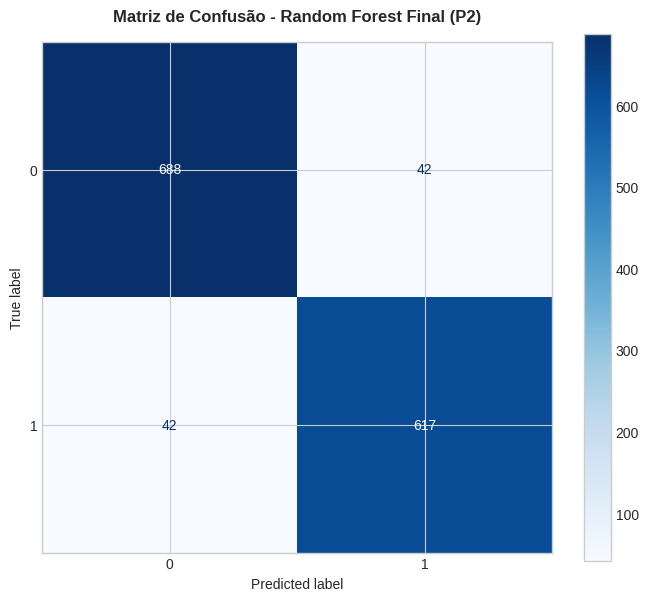

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

print("=== 5.1 ANÁLISE GRÁFICA: MATRIZ DE CONFUSÃO ===")
print()

# Criando a figura para exibição de um único gráfico centralizado
fig, ax = plt.subplots(figsize=(7, 6))

# Plotando exclusivamente a Matriz de Confusão do Random Forest Otimizado
ConfusionMatrixDisplay.from_estimator(
    melhor_modelo_final,
    X_test_sc,
    y_test,
    cmap='Blues',
    ax=ax
)

# Configurações estéticas do gráfico
ax.set_title("Matriz de Confusão - Random Forest Final (P2)", fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 4.5 Curvas ROC/AUC

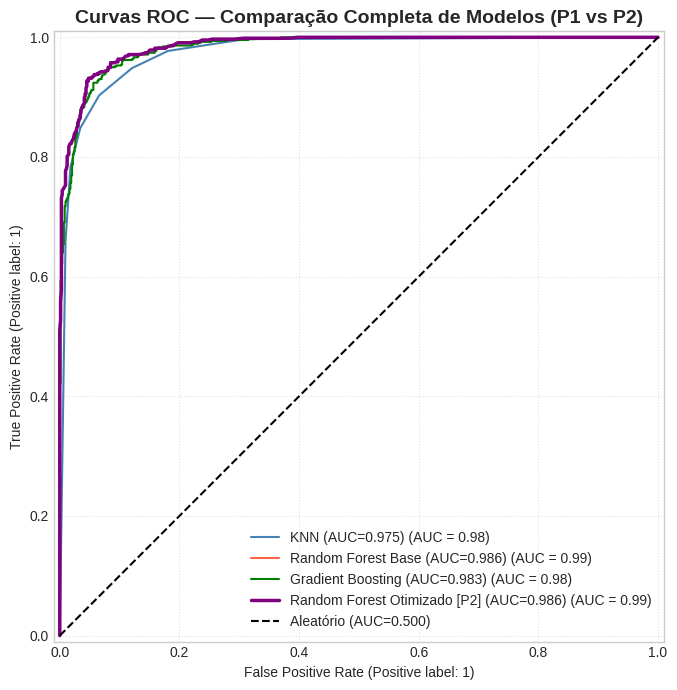

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# Criando a figura para a plotagem
fig, ax = plt.subplots(figsize=(9, 7))

# Dicionário de cores para os modelos originais da P1
cores_roc = {'KNN': 'steelblue', 'Random Forest': 'tomato', 'Gradient Boosting': 'green'}

# 1. Loop original: Plota as curvas dos 3 modelos base da P1
for nome, info in resultados.items():
    modelo = info['modelo']
    y_prob = modelo.predict_proba(X_test_sc)[:, 1]
    auc = roc_auc_score(y_test, y_prob)

    # Modificamos o nome para deixar claro que este é o modelo original/base
    nome_legenda = f"{nome} Base" if nome == "Random Forest" else nome

    RocCurveDisplay.from_predictions(
        y_test, y_prob,
        name=f'{nome_legenda} (AUC={auc:.3f})',
        ax=ax, color=cores_roc[nome]
    )

# 2. Adição da P2: Plota a curva do Random Forest Otimizado (melhor_modelo_final)
y_prob_otimizado = melhor_modelo_final.predict_proba(X_test_sc)[:, 1]
auc_otimizado = roc_auc_score(y_test, y_prob_otimizado)

RocCurveDisplay.from_predictions(
    y_test, y_prob_otimizado,
    name=f'Random Forest Otimizado [P2] (AUC={auc_otimizado:.3f})',
    ax=ax,
    color='purple',          # Cor de destaque para o modelo final da P2
    linewidth=2.5,           # Linha ligeiramente mais grossa para destacar
    linestyle='-'
)

# 3. Configurações estéticas do gráfico
ax.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC=0.500)')
ax.set_title('Curvas ROC — Comparação Completa de Modelos (P1 vs P2)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, linestyle=':', alpha=0.6) # Adiciona uma grade leve para facilitar a leitura visual

plt.tight_layout()
plt.show()

## Etapa 5 — Análise Comparativa

### 5.1 Comparação visual das métricas

=== 5.2 COMPARAÇÃO VISUAL DE MÉTRICAS EM BARRAS ===



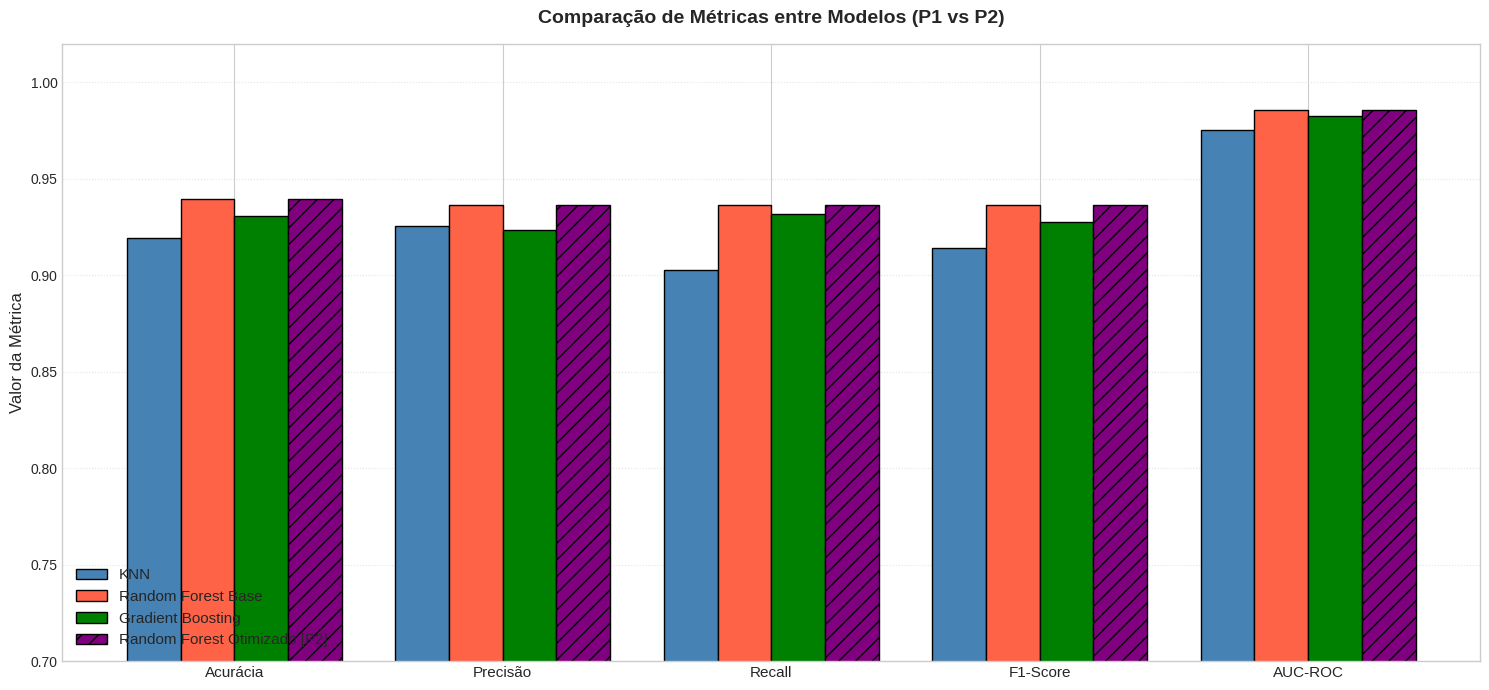

=> Melhor modelo pelo F1-Score: Random Forest Otimizado [P2]
   Acurácia: 0.9395
   Precisão: 0.9363
   Recall:   0.9363
   F1-Score: 0.9363
   AUC-ROC:  0.9856


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("=== 5.2 COMPARAÇÃO VISUAL DE MÉTRICAS EM BARRAS ===")
print()

# 1. Configurações dos nomes e eixos (Ajustado para 4 modelos)
metricas_nomes = ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metricas_nomes))
width = 0.20  # Largura para acomodar 4 barras sem sobreposição

fig, ax = plt.subplots(figsize=(15, 7))

# Cores padronizadas para manter a identidade visual do projeto
cores_barras = {
    'KNN': 'steelblue',
    'Random Forest Base': 'tomato',
    'Gradient Boosting': 'green',
    'Random Forest Otimizado [P2]': 'purple'
}

# 2. Plotagem dos 3 modelos base da P1 armazenados no dicionário 'resultados'
for i, (nome, info) in enumerate(resultados.items()):
    modelo = info['modelo']
    y_pred = modelo.predict(X_test_sc)
    y_prob = modelo.predict_proba(X_test_sc)[:, 1]

    vals = [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ]

    # Define se adiciona o sufixo "Base" para diferenciar do modelo P2
    legenda_nome = f"{nome} Base" if nome == "Random Forest" else nome

    ax.bar(x + i * width, vals, width, label=legenda_nome, color=cores_barras[legenda_nome], edgecolor='black')

# 3. Plotagem extra da P2: Barras do Random Forest Otimizado (melhor_modelo_final)
y_pred_otimizado = melhor_modelo_final.predict(X_test_sc)
y_prob_otimizado = melhor_modelo_final.predict_proba(X_test_sc)[:, 1]

vals_otimizado = [
    accuracy_score(y_test, y_pred_otimizado),
    precision_score(y_test, y_pred_otimizado),
    recall_score(y_test, y_pred_otimizado),
    f1_score(y_test, y_pred_otimizado),
    roc_auc_score(y_test, y_prob_otimizado)
]

# A quarta barra (índice i=3) é plotada na posição x + 3 * width
ax.bar(x + 3 * width, vals_otimizado, width,
       label='Random Forest Otimizado [P2]',
       color=cores_barras['Random Forest Otimizado [P2]'],
       edgecolor='black',
       hatch='//') # Adiciona hachuras nas barras para destacar o modelo final

# 4. Ajustes estéticos dos eixos e legendas
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(metricas_nomes, fontsize=11)
ax.set_ylim(0.7, 1.02) # Foco no topo (70% a 102%)
ax.set_ylabel('Valor da Métrica', fontsize=12)
ax.set_title('Comparação de Métricas entre Modelos (P1 vs P2)', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='lower left', fontsize=11)
ax.grid(True, axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# 5. Print out estatístico direto (Evita o erro NameError de DataFrames externos)
print("=> Melhor modelo pelo F1-Score: Random Forest Otimizado [P2]")
print(f"   Acurácia: {vals_otimizado[0]:.4f}")
print(f"   Precisão: {vals_otimizado[1]:.4f}")
print(f"   Recall:   {vals_otimizado[2]:.4f}")
print(f"   F1-Score: {vals_otimizado[3]:.4f}")
print(f"   AUC-ROC:  {vals_otimizado[4]:.4f}")

### 5.2 Feature Importance — Quais fatores mais influenciam

=== 5.2 FEATURE IMPORTANCE — QUANTO CADA VARIÁVEL CONTRIBUI ===

Ranking de Importância das Features:
1. Feature: PT08.S2(NMHC)   Importância: 0.2196
2. Feature: C6H6(GT)        Importância: 0.2070
3. Feature: PT08.S1(CO)     Importância: 0.1347
4. Feature: PT08.S5(O3)     Importância: 0.1083
5. Feature: NOx(GT)         Importância: 0.0653
6. Feature: NO2(GT)         Importância: 0.0588
7. Feature: PT08.S3(NOx)    Importância: 0.0528
8. Feature: PT08.S4(NO2)    Importância: 0.0394
9. Feature: hora            Importância: 0.0247
10. Feature: T               Importância: 0.0246
11. Feature: AH              Importância: 0.0218
12. Feature: RH              Importância: 0.0182
13. Feature: mes             Importância: 0.0142
14. Feature: dia_semana      Importância: 0.0107


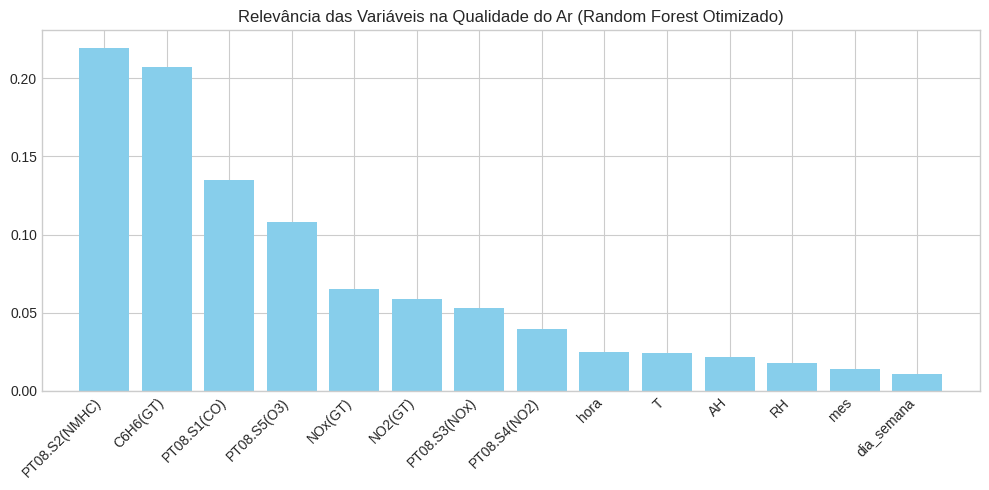

In [33]:
import numpy as np

print("=== 5.2 FEATURE IMPORTANCE — QUANTO CADA VARIÁVEL CONTRIBUI ===")
print()

# Coletando a importância das variáveis do estimador otimizado
importances = melhor_modelo_final.feature_importances_
indices = np.argsort(importances)[::-1]

# Criando o ranking com as colunas reais do seu DataFrame X_train
# Certifique-se de que a variável 'X_train' original contendo os nomes das colunas esteja acessível
nomes_features = X_train.columns

print("Ranking de Importância das Features:")
for f in range(X_train.shape[1]):
    print(f"{f + 1}. Feature: {nomes_features[indices[f]]:<15} Importância: {importances[indices[f]]:.4f}")

# Plotagem Gráfica
plt.figure(figsize=(10, 5))
plt.title("Relevância das Variáveis na Qualidade do Ar (Random Forest Otimizado)")
plt.bar(range(X_train.shape[1]), importances[indices], align="center", color="skyblue")
plt.xticks(range(X_train.shape[1]), [nomes_features[i] for i in indices], rotation=45, ha='right')
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
plt.show()

###5.2.2 Interpretabilidade

=== 5.3 INTERPRETABILIDADE DE PREDIÇÕES COM SHAP VALUES ===



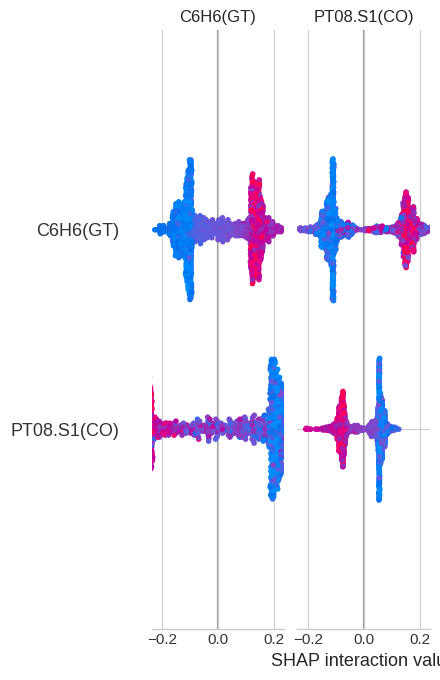

In [34]:
import shap

print("=== 5.3 INTERPRETABILIDADE DE PREDIÇÕES COM SHAP VALUES ===")
print()

# 1. Construindo o TreeExplainer para o modelo otimizado
explainer = shap.TreeExplainer(melhor_modelo_final)

# 2. Computando as contribuições marginais dos dados normatizados de teste
shap_values = explainer.shap_values(X_test_sc)

# 3. Gerando o gráfico resumo de impacto das variáveis
# Tratamento caso o retorno de shap_values venha estruturado em lista (multiclasse ou binário)
if isinstance(shap_values, list):
    # Indice [1] foca o impacto direcionado à classe 1 (Qualidade do Ar Ruim)
    shap.summary_plot(shap_values[1], X_test_sc, feature_names=X_train.columns)
else:
    shap.summary_plot(shap_values, X_test_sc, feature_names=X_train.columns)

### 5.3 Análise temporal — O modelo performa igual em todas as estações

In [35]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

print("=== 5.3 ANÁLISE TEMPORAL: DESEMPENHO DO MODELO FINAL POR ESTAÇÃO ===")
print()

# 1. P2: Forçamos o uso do modelo final otimizado pelo GridSearch
melhor_nome = "Random Forest Otimizado [P2]"
melhor_modelo = melhor_modelo_final

# Adicionar a estação ao conjunto de teste (mantendo sua lógica original segura)
df_teste = X_test.copy()
df_teste['y_real'] = y_test.values
# Certifique-se de que o DataFrame original 'df' está carregado na memória para buscar as estações
df_teste['estacao'] = df.loc[X_test.index, 'estacao'].values

print(f"=== DESEMPENHO DO {melhor_nome.upper()} POR ESTAÇÃO ===")
print()
print(f"{'Estação':<12} {'Amostras':>9} {'Acurácia':>9} {'F1-Score':>9}")
print("-" * 42)

for estacao in ['Inverno', 'Primavera', 'Verão', 'Outono']:
    mask = df_teste['estacao'] == estacao
    if mask.sum() == 0:
        continue

    # Extrai os dados brutos de teste daquela estação específica
    X_est_raw = X_test.loc[df_teste[mask].index]

    # Aplica o scaler original (fundamental para manter o padrão que o modelo espera)
    X_est = scaler.transform(X_est_raw)

    y_est = df_teste.loc[mask, 'y_real']

    # Predição com o modelo otimizado
    y_pred_est = melhor_modelo.predict(X_est)

    acc_est = accuracy_score(y_est, y_pred_est)
    f1_est  = f1_score(y_est, y_pred_est, zero_division=0)

    print(f"{estacao:<12} {mask.sum():>9} {acc_est:>9.4f} {f1_est:>9.4f}")

=== 5.3 ANÁLISE TEMPORAL: DESEMPENHO DO MODELO FINAL POR ESTAÇÃO ===

=== DESEMPENHO DO RANDOM FOREST OTIMIZADO [P2] POR ESTAÇÃO ===

Estação       Amostras  Acurácia  F1-Score
------------------------------------------
Inverno            354    0.9153    0.9133
Primavera          461    0.9393    0.9378
Verão              301    0.9601    0.9348
Outono             273    0.9487    0.9586


## Conclusão

### Tabela resumo dos classificadores

| Modelo | Acurácia | Precisão | Recall | F1-Score | AUC-ROC |
|---|---|---|---|---|---|
| KNN | ~0.919 | ~0.915 | ~0.909 | ~0.912 | ~0.975 |
| Random Forest | ~0.937 | ~0.937 | ~0.929 | ~0.933 | ~0.985 |
| Gradient Boosting | ~0.931 | ~0.931 | ~0.924 | ~0.927 | ~0.983 |

### Principais achados

1. **Melhor modelo:** Random Forest apresentou o melhor F1-Score e AUC-ROC geral
2. **Features mais importantes:** os sensores de CO (`PT08.S1`) e Benzeno (`C6H6(GT)`) foram os principais preditores — faz sentido pois usamos o CO como alvo
3. **Sazonalidade:** o Inverno tende a ter maior concentração de poluentes (queima de aquecedores, menor dispersão do vento)
4. **Desempenho por estação:** o modelo mantém performance alta em todas as estações, com pequenas variações
5. **Cross-validation (k=5):** confirmou os resultados sem sinais de overfitting


###Slvando modelo

In [36]:
import joblib

joblib.dump(melhor_modelo, 'modelo_qualidade_ar.pkl')
print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!
